# Import libraries

In [37]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
import argparse

import sys
sys.path.append("..")
from ml_solver import MLSolver, DeepONet, FNOforPDE
from data_generation import GaussianRandomField, PDEDataset2, GaussianRandomFieldHierarchical
from pde import PoissonEquation1D, PoissonEquation2D, HelmholtzEquation1D, HelmholtzEquation2D
from numerical_solver import WeightedJacobiSolver, MultigridSolver, GaussSeidelSolver
from hybrid_solver import Router, ConstantRouter, HINTSRouter, LSTMGreedyRouter, HybridSolver


from trainer import Trainer, EarlyStopping, ApproxGreedyRouterLoss, ScheduledSampler
import json
import latextable
import pickle
import pandas as pd
from texttable import Texttable

In [38]:
max_iters = 300

# Function to test any given hybrid solver

In [39]:
def test_model(model, dataloader, in_channels, dim, loss = ApproxGreedyRouterLoss(), centered = True, loss_t = False):
    model.eval()
    errors_greedy = ()
    loss_greedy = () if loss_t else None
    residuals = ()
    solver_decisions = ()
    mode_1_errors = ()
    mode_5_errors = ()
    mode_10_errors = ()
    with torch.no_grad():
        for batch in dataloader:
            model.reset()
            input, output = batch
            bs = input.shape[0]
            # f = input[:, 0, :].reshape(bs, -1)
            # if in_channels > 1:
            #     a = input[:, 1, :].reshape(bs, -1)
            # else:
            #     a = None
            f = input[:, -1, :].reshape(bs, -1)
            if model.equation.equation == "Poisson":
                if in_channels > 1:
                    a = input[:, 0, :].reshape(bs, -1)
                else:
                    a = None
                k2 = None
            else:
                k2 = input[:, -2, :].reshape(bs, -1)
                if in_channels > 1:
                    a = input[:, 0, :].reshape(bs, -1)
                else:
                    a = None
            pred = model(f = f, a = a, k2 = k2, u0=None, return_dict = True, training=loss, ground_truth = output.reshape(bs, -1))
            if centered:
                predictions = pred["predictions"] - torch.mean(pred["predictions"], axis = 2, keepdim = True)
            else:
                predictions =  pred["predictions"] 
            initial_prediction = torch.zeros_like(predictions[0]).unsqueeze(0)
            predictions = torch.cat((initial_prediction, predictions), dim = 0)
            # initial_error = torch.norm()
            error = torch.norm(predictions - output.reshape(bs, -1).unsqueeze(0), dim=2).detach().cpu().numpy()
            scores = pred["routing_scores"]
            decisions = torch.argmax(scores, dim = -1).detach().cpu().numpy()
            solver_decisions += (decisions,)
            residual = torch.norm(pred["residuals"], dim = 2).detach().cpu().numpy()
            residuals += (residual, )
            errors_greedy += (error,)
            if loss_t:
                loss_greedy += (loss(pred, output.reshape(bs, -1), "none").detach().cpu().numpy(), )
            error = (predictions - output.reshape(bs, -1).unsqueeze(0)).detach().cpu().numpy()
                        
            if dim == 1:
                mode_wise_error = np.fft.rfftn(error, axes = [-1])
                mode_1_error = mode_wise_error[:, :, 1]
                mode_1_norm = np.sqrt(mode_1_error.real**2 + mode_1_error.imag**2)
                mode_5_error = mode_wise_error[:, :, 5]
                mode_5_norm = np.sqrt(mode_5_error.real**2 + mode_5_error.imag**2)

                mode_10_error = mode_wise_error[:, :, 10]
                mode_10_norm = np.sqrt(mode_10_error.real**2 + mode_10_error.imag**2)

            else:
                N = int(np.sqrt(error.shape[2]))
                error = error.reshape(error.shape[0], error.shape[1], N, N)
                mode_wise_error = np.fft.rfftn(error, axes = [-2,-1])
                mode_1_error = mode_wise_error[:, :, 1, 1]
                mode_1_norm = np.sqrt(mode_1_error.real**2 + mode_1_error.imag**2)
                mode_5_error = mode_wise_error[:, :, 5, 5]
                mode_5_norm = np.sqrt(mode_5_error.real**2 + mode_5_error.imag**2)

                mode_10_error = mode_wise_error[:, :, 10, 10]
                mode_10_norm = np.sqrt(mode_10_error.real**2 + mode_10_error.imag**2)
            mode_1_errors += (mode_1_norm,)
            mode_5_errors += (mode_5_norm,)
            mode_10_errors += (mode_10_norm,)

    errors_greedy = np.concatenate(errors_greedy, axis = 1)
    loss_greedy = np.concatenate(loss_greedy) if loss_t else None
    residuals = np.concatenate(residuals, axis = 1)
    mode_1_errors = np.concatenate(mode_1_errors, axis = 1)
    mode_5_errors = np.concatenate(mode_5_errors, axis = 1)
    mode_10_errors = np.concatenate(mode_10_errors, axis = 1)
    solver_decisions = np.concatenate(solver_decisions, axis = 1)
    return errors_greedy, loss_greedy, residuals, mode_1_errors, mode_5_errors, mode_10_errors, solver_decisions


In [40]:
def visualize_predictions_truth(deeponet, dataloader):
    with torch.no_grad():
        for batch in dataloader:
            input, output = batch
            bs = input.shape[0]
            print(input.shape)
            if input.shape[1] > 1:
                input = input[:, -1, :].reshape(bs, -1)
            pred = deeponet(input)
            print(pred.shape)
            pred = pred - torch.mean(pred, dim = (1, 2), keepdim = True) if equation == "Poisson" and boundary == "Periodic" and in_channels == 1 else pred
            break
    import matplotlib.pyplot as plt
    from matplotlib.colors import Normalize
    fig, axs = plt.subplots(2, 4, figsize=(16, 8))
    print(pred.shape)
    print(output.shape)
    # mse = torch.linalg.norm(pred - output, dim = (1,2))/torch.linalg.norm(output, dim = (1,2))
    # print(mse)
    # make sure all plots in the same column have the same color bar
    # datasets = [[pred[i].cpu().numpy().reshape(deeponet.N, deeponet.N), output[i].cpu().numpy().reshape(deeponet.N, deeponet.N)] for i in range(4)]
    # norm = Normalize(vmin = np.min(datasets), vmax = np.max(datasets))
    for i in range(4):
        datasets = [pred[i].cpu().numpy().reshape(deeponet.N, deeponet.N), output[i].cpu().numpy().reshape(deeponet.N, deeponet.N)]
        norm = Normalize(vmin = np.min(datasets[1]), vmax = np.max(datasets[1]))
        if i == 2:
            print(pred[i].cpu().numpy().reshape(deeponet.N, deeponet.N)[0])
            print(output[i].cpu().numpy().reshape(deeponet.N, deeponet.N)[0])
        axs[0][i].imshow(output[i].cpu().numpy().reshape(deeponet.N, deeponet.N), norm = norm)
        axs[0][i].set_title(f"Truth: sample {i}")
        axs[1][i].imshow(pred[i].cpu().numpy().reshape(deeponet.N, deeponet.N), norm = norm)
        axs[1][i].set_title(f"Predicted: sample {i}")
        cbar = axs[1][i].figure.colorbar(axs[1][i].imshow(pred[i].cpu().numpy().reshape(deeponet.N, deeponet.N), norm = norm), ax = axs[1][i])
        cbar = axs[0][i].figure.colorbar(axs[0][i].imshow(output[i].cpu().numpy().reshape(deeponet.N, deeponet.N), norm = norm), ax = axs[0][i])
    plt.show()

                

# Function to test the true greedy hybrid solver

In [41]:
def true_greedy_model(model_hints, test_loader):
    errors_true_greedy = ()
    loss_true_greedy = ()
    best_solvers = ()
    with torch.no_grad():
        for batch in test_loader:
            model_hints.reset()
            input, output = batch
            bs = input.shape[0]
            f = input[:, -1, :].reshape(bs, -1)
            if model_hints.equation.equation == "Poisson":
                if in_channels > 1:
                    a = input[:, 0, :].reshape(bs, -1)
                else:
                    a = None
                k2 = None
            else:
                k2 = input[:, -2, :].reshape(bs, -1)
                if in_channels > 1:
                    a = input[:, 0, :].reshape(bs, -1)
                else:
                    a = None
            
            pred = model_hints(f = f, a = a, k2=k2, u0=None, return_dict = True, training=True, teacher_forcing = 1.0, ground_truth = output.reshape(bs, -1))
            if model_hints.equation.equation == "Poisson" and model_hints.equation.boundary == "Periodic":
                expert_predictions = pred["complete_expert_predictions"] - torch.mean(pred["complete_expert_predictions"], dim=-1, keepdim=True)
            else:
                expert_predictions = pred["complete_expert_predictions"]
            print(expert_predictions.shape)
            errors_expert = torch.norm(expert_predictions - output.reshape(bs, -1).unsqueeze(0), dim=-1)
            best_solver = torch.argmin(errors_expert, dim=1)
            scores = torch.zeros(max_iters, input.shape[0], 2, device = device)
            scores = torch.nn.functional.one_hot(best_solver, num_classes=2).to(scores.dtype)
            pred["routing_scores"] = scores 
            
            loss_true_greedy += (loss(pred, output.reshape(bs, -1), "none").detach().cpu().numpy(), )
            initial_prediction = torch.zeros_like(expert_predictions[0]).unsqueeze(0)
            expert_predictions = torch.cat((initial_prediction, expert_predictions), dim = 0)
            errors_expert = torch.norm(expert_predictions - output.reshape(bs, -1).unsqueeze(0), dim=-1)
            best_error = torch.min(errors_expert, dim=1).values.detach().cpu().numpy()
            errors_true_greedy += (best_error,)
            best_solvers += (best_solver.detach().cpu().numpy(),)
    errors_true_greedy = np.concatenate(errors_true_greedy, axis=1)
    loss_true_greedy = np.concatenate(loss_true_greedy)
    best_solvers = np.concatenate(best_solvers, axis=1)
    return errors_true_greedy, best_solvers

# Set the parameters

In [42]:
ml_model_type = "deeponet"
ml_model_name = "msealphaepsilon_loss_new_data4"
model_type = "lstm"
model_name = "trying_something_3"
equation = "Poisson"
boundary = "Periodic"
dim = 2
in_channels = 1
ckp_dir = f"/nfs/turbo/lsa-tewaria/sahana/greedy/poisson/checkpoints"
solvers = "jacobi" # "jacobi_0.5,jacobi_0.67,jacobi_0.75,jacobi_0.8,jacobi"#,jacobi,jacobi_0.8"
grf_mode = "hierarchical"
n_samples = 64
n_test = n_samples
data_dir = "/nfs/turbo/lsa-tewaria/sahana/greedy/poisson/data"
data_name = "new_new_new_"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generate = False

# Load the ML solver arguments and Router arguments

In [43]:
ml_ckp_path = ckp_dir + f"/{ml_model_type}_{ml_model_name}_{grf_mode}_{equation}_{boundary}_{dim}d_{in_channels}c_best.pth"
ml_args_path = ckp_dir + f"/{ml_model_type}_{ml_model_name}_{grf_mode}_{equation}_{boundary}_{dim}d_{in_channels}c_args.json"

args_path = ckp_dir + f"/{model_type}router_{model_name}_{equation}_{boundary}_{dim}d_{in_channels}c_{solvers}args.json"
if os.path.exists(args_path):
    print(f"Loading training arguments from {args_path}...")
    with open(args_path, "r") as f:
        arguments = json.load(f)
    
if os.path.exists(ml_args_path):
    with open(ml_args_path, "r") as f:
        ml_arguments = json.load(f)
else:
    raise ValueError("ML Args Path Not found")

# Generate some test data

In [44]:
if os.path.exists(f"{data_dir}/{data_name}router_test_data_{grf_mode}_{equation}_{boundary}_{dim}d_{in_channels}c_{n_test}s.pt"):
    print(f"Loading data from {data_dir}...")
    with open(f"{data_dir}/{data_name}router_test_data_{grf_mode}_{equation}_{boundary}_{dim}d_{in_channels}c_{n_test}s.pt", "rb") as f:
        test_data = torch.load(f)
if generate:
# else:
    if grf_mode == "fixed":
        with open(f"../args/grf_args.json", "r") as f:
            arguments_grf = json.load(f)
        grf = GaussianRandomField(num_samples=ml_arguments["N"],
                                    dim=dim,
                                    alpha=arguments_grf["alpha"],
                                    beta=arguments_grf["beta"],
                                    gamma=arguments_grf["gamma"],
                                    device=device,
                                    seed = 72)
    else:
        with open(f"../args/hierarchical_grf.json", "r") as f:
            arguments_grf = json.load(f)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        grf = GaussianRandomFieldHierarchical(num_samples=ml_arguments["N"],dim=dim,
                                                alpha_min=arguments_grf["alpha_min"],
                                                        alpha_max=arguments_grf["alpha_max"],
                                                        beta_min=arguments_grf["beta_min"],
                                                        beta_max=arguments_grf["beta_max"],
                                                        gamma_list=arguments_grf["gamma_list"],
                                                        device=device, seed=4)

    pushforward = None if boundary == "Dirichlet" else lambda x: x - torch.mean(x)
    f = grf.generate(n_samples, pushfoward=pushforward) if equation == "Poisson" and in_channels == 1 else grf.generate(n_samples, pushfoward=None)
    # if equation == "Poisson" or (equation == "Helmholtz" and in_channels > 1):
    #     f = grf.generate(n_samples, pushfoward=pushforward) if equation == "Poisson" and in_channels == 1 else grf.generate(n_samples, pushfoward=None)
    # else:
    #     if dim == 1:
    #         f = lambda x: 0.0
    #     else:
    #         f = lambda x, y: 0.0

    k2 = grf.generate(n_samples)
    if in_channels > 1:
        a = grf.generate(n_samples)
    else:
        if dim == 1:
            a = lambda x: 1.0
        else:
            a = lambda x, y: 1.0
    if boundary == "Dirichlet":
        x = torch.linspace(0, 1, ml_arguments["N"], device=device, dtype=torch.float32)
        y = torch.linspace(0, 1, ml_arguments["N"], device=device, dtype=torch.float32) if dim ==2 else None
    else:
        x = torch.linspace(0, 1, ml_arguments["N"] + 1, device=device, dtype=torch.float32)[:-1]
        y = torch.linspace(0, 1, ml_arguments["N"] + 1, device=device, dtype=torch.float32)[:-1] if dim ==2 else None

    # Here I want to leverage our new batch friendly pde objects
    pde = None
    u_sol = None
    if dim == 1:
        if equation == "Poisson":
            pde = PoissonEquation1D(a_func=a, 
                                    f_func=f, 
                                    boundary=boundary, 
                                    x=x, device=device)
        else:
            pde = HelmholtzEquation1D(a_func=a, f_func=f, k2=k2, boundary=boundary,x=x,device=device)
        u_sol = torch.tensor(pde.u, dtype=torch.float32, device=device)
        u_sol = u_sol - torch.mean(u_sol, dim = -1, keepdim=True) if equation == "Poisson" and boundary == "Periodic" and in_channels == 1 else u_sol
    else:
        if equation == "Poisson":
            pde = PoissonEquation2D(a_func=a.reshape(-1, ml_arguments["N"] * ml_arguments["N"]) if in_channels > 1 else a, 
                                    f_func=f.reshape(-1, ml_arguments["N"] * ml_arguments["N"]),
                                    boundary=boundary, 
                                    x=x, y=y, device=device)
        else:
            pde = HelmholtzEquation2D(a_func=a.reshape(-1, ml_arguments["N"] * ml_arguments["N"]) if in_channels > 1 else a, 
                                        f_func=f.reshape(-1, ml_arguments["N"] * ml_arguments["N"]), 
                                        k2=k2.reshape(-1, ml_arguments["N"] * ml_arguments["N"]),
                                        boundary=boundary, x=x, y=y, device=device)
        u_sol = torch.tensor(pde.u, dtype=torch.float32, device=device)
        u_sol = u_sol - torch.mean(u_sol, dim=(-2,-1), keepdim=True) if equation == "Poisson" and boundary == "Periodic" and in_channels == 1 else u_sol
    if in_channels > 1:
        if equation == "Poisson":
            input = torch.concatenate((a[:, None, :], f[:, None, :]), dim=1)
        else:
            input = torch.concatenate((a[:, None, :], k2[:, None, :], f[:, None, :]), dim=1)
    else:
        if equation == "Poisson":
            input = f[:, None, :]
        else:
            input = torch.concatenate((k2[:, None, :], f[:, None, :]), dim=1)
    test_data = [input, u_sol]
test_dataset = PDEDataset2(test_data)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=16, shuffle=False)

Loading data from /nfs/turbo/lsa-tewaria/sahana/greedy/poisson/data...


# Load the ML model

In [45]:
new_in_channels = in_channels + 1 if equation == "Helmholtz" else in_channels
if ml_model_type == "deeponet":
    ml_model = DeepONet(N=ml_arguments["N"], dim=dim, in_channels=new_in_channels, device=device, boundary=boundary,
                    branch_dim=ml_arguments["branch_dim"],
                    hidden_branch=ml_arguments["hidden_branch"],
                    num_branch_layers=ml_arguments["num_branch_layers"],
                    hidden_trunk=ml_arguments["hidden_trunk"],
                    num_trunk_layers=ml_arguments["num_trunk_layers"]).to(device)
elif ml_model_type == "fno":
    ml_model = FNOforPDE(trunc_mode=ml_arguments["trunc_mode"], dim=dim, in_channels=new_in_channels,
                        hidden_size=ml_arguments["hidden_size"], num_layers=ml_arguments["num_layers"]).to(device)


ml_ckp = None
if os.path.exists(ml_ckp_path):
    print(f"Loading ml model checkpoint from {ml_ckp_path}...")
    ml_ckp = torch.load(ml_ckp_path, map_location=device, weights_only=False)

if ml_ckp:
    ml_model.load_state_dict(ml_ckp["model"])


Loading ml model checkpoint from /nfs/turbo/lsa-tewaria/sahana/greedy/poisson/checkpoints/deeponet_msealphaepsilon_loss_new_data4_hierarchical_Poisson_Periodic_2d_1c_best.pth...


torch.Size([16, 1, 31, 31])
torch.Size([16, 31, 31])
torch.Size([16, 31, 31])
torch.Size([16, 31, 31])
[-1.3862195e-05 -4.1684407e-06  7.4561094e-06  2.0778196e-05
  3.8630817e-05  5.5593526e-05  7.0209629e-05  8.2152408e-05
  9.0113237e-05  9.5155032e-05  9.4823903e-05  8.7126333e-05
  7.7621626e-05  6.5688917e-05  4.9483544e-05  3.1997515e-05
  1.2794741e-05 -5.6577146e-06 -2.3397341e-05 -3.7361755e-05
 -4.7360529e-05 -5.7066372e-05 -6.7156761e-05 -7.0298142e-05
 -7.1676004e-05 -7.0112837e-05 -6.5673528e-05 -6.0204238e-05
 -4.9425304e-05 -3.5395307e-05 -2.5996927e-05]
[-1.2696348e-05  4.5046909e-06  2.1439848e-05  3.7315818e-05
  5.1391762e-05  6.3124542e-05  7.2152441e-05  7.8355290e-05
  8.1661608e-05  8.2059451e-05  7.9573889e-05  7.4160693e-05
  6.5923086e-05  5.5099321e-05  4.2143081e-05  2.7609869e-05
  1.2051947e-05 -3.9250845e-06 -1.9672631e-05 -3.4486897e-05
 -4.7753012e-05 -5.9125843e-05 -6.8256537e-05 -7.4786949e-05
 -7.8350458e-05 -7.8548241e-05 -7.5227763e-05 -6.8315880e

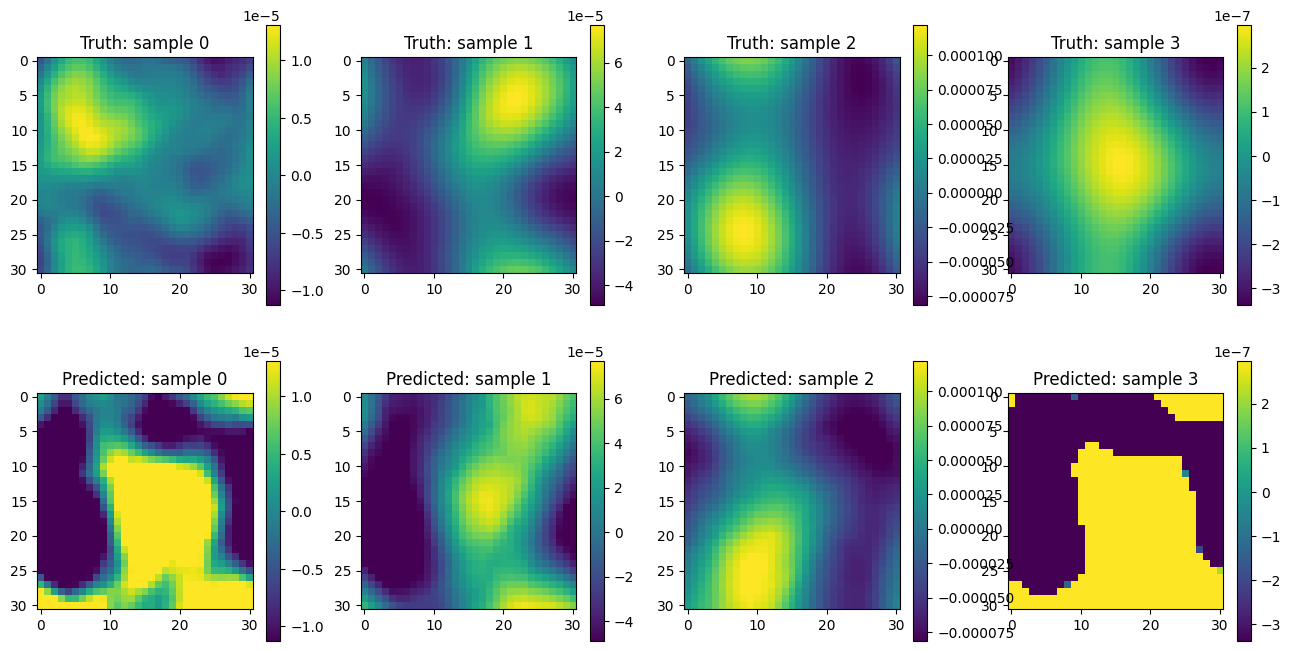

In [46]:
visualize_predictions_truth(ml_model, test_loader)

# Load the trained router

In [47]:
ckp_path = ckp_dir + f"/{model_type}router_{model_name}_{grf_mode}_{equation}_{boundary}_{dim}d_{in_channels}c_{solvers}_best.pth"
save_path = ckp_dir + f"/{model_type}router_{model_name}_{grf_mode}_{equation}_{boundary}_{dim}d_{in_channels}c_{solvers}"
args_path = ckp_dir + f"/{model_type}router_{model_name}_{grf_mode}_{equation}_{boundary}_{dim}d_{in_channels}c_{solvers}args.json"
print(args_path)
if os.path.exists(args_path):
    print(f"Loading training arguments from {args_path}...")
    with open(args_path, "r") as f:
        arguments = json.load(f)
else:
    raise ValueError("Router Args Path Not found")
if model_type == "lstm":
    print(f"HERE")
    if dim == 1:
        router = LSTMGreedyRouter(None, ml_arguments["N"]*(new_in_channels + 1), arguments["hidden_dim"], arguments["num_layers"], 2, arguments["dropout"]).to(device)
    else:
        router = LSTMGreedyRouter(None, ml_arguments["N"]*ml_arguments["N"]*(new_in_channels + 1), arguments["hidden_dim"], arguments["num_layers"], 2, arguments["dropout"]).to(device)
    # router = LSTMGreedyRouter(None, ml_arguments["N"]*(in_channels + 1), arguments["hidden_dim"], arguments["num_layers"], num_solvers, arguments["dropout"]).to(device)
ckp = None
if os.path.exists(ckp_path):
    print(f"Loading model checkpoint from {ckp_path}...")
    ckp = torch.load(ckp_path, map_location=device)

if ckp:
    print(f"Loading router state dict...")
    router.load_state_dict(ckp["model"])
    print(f"Loaded router state dict")
if boundary == "Dirichlet":
    x = torch.linspace(0, 1, arguments["N"], device=device, dtype=torch.float32)
    y = torch.linspace(0, 1, arguments["N"], device=device, dtype=torch.float32) if dim ==2 else None
else:
    x = torch.linspace(0, 1, arguments["N"] + 1, device=device, dtype=torch.float32)[:-1]
    y = torch.linspace(0, 1, arguments["N"] + 1, device=device, dtype=torch.float32)[:-1] if dim ==2 else None
pde = None
if equation == "Poisson":
    if dim == 1:
        pde = PoissonEquation1D(a_func= lambda x: 1,
                                f_func=lambda x: 1,
                                boundary=boundary,
                                x=x, 
                                device=device, 
                                solve = False)
    else:
        pde = PoissonEquation2D(a_func=lambda x, y: 1,
                                        f_func=lambda x,y: 1,
                                        boundary=boundary,
                                        x=x,
                                        y=y,
                                        device=device, 
                                        solve = False)
else:
    if dim == 1:
        pde = HelmholtzEquation1D(a_func= lambda x: 1, f_func=lambda x: 1, k2=lambda x: 1, boundary=boundary, x=x, device=device, solve = False)
    else:
        pde = HelmholtzEquation2D(a_func=lambda x, y: 1,f_func=lambda x,y: 1, k2=lambda x,y: 1, boundary=boundary,x=x,y=y, device=device, solve = False)


/nfs/turbo/lsa-tewaria/sahana/greedy/poisson/checkpoints/lstmrouter_trying_something_3_hierarchical_Poisson_Periodic_2d_1c_jacobiargs.json
Loading training arguments from /nfs/turbo/lsa-tewaria/sahana/greedy/poisson/checkpoints/lstmrouter_trying_something_3_hierarchical_Poisson_Periodic_2d_1c_jacobiargs.json...
HERE
Loading model checkpoint from /nfs/turbo/lsa-tewaria/sahana/greedy/poisson/checkpoints/lstmrouter_trying_something_3_hierarchical_Poisson_Periodic_2d_1c_jacobi_best.pth...
Loading router state dict...
Loaded router state dict


In [48]:
list_of_solvers = []
numerical_solvers = solvers.split(",")
for solver in numerical_solvers:
    split = solver.split("_")
    print(solver)
    if len(split) > 2:
        raise ValueError("Invalid Numerical Solver")
    if split[0] == "jacobi":
        if len(split) > 1:
            weight = float(split[1])
        else:
            weight = 1
        list_of_solvers.append(WeightedJacobiSolver(pde, device, weight))
    elif split[0] == "gs":
        list_of_solvers.append(GaussSeidelSolver(pde, device))
    elif split[0] == "mg":
        if len(split) > 1:
            levels = int(split[1])
        else:
            levels = 2
        print(f"This is device {device}")
        list_of_solvers.append(MultigridSolver(pde, levels, device))
    else:
        raise ValueError("Invalid Numerical Solver")
print(list_of_solvers)
centered = equation == "Poisson" and boundary == "Periodic" and in_channels == 1

jacobi


# Test the hybrid solver with the learned router

In [49]:
model = HybridSolver(N=ml_arguments["N"], dim=dim, in_channels=in_channels, boundary=boundary, equation=pde,
                                    suite_solver=list_of_solvers+[ml_model], router=router, tol=1e-7, max_iters=arguments["max_iters"], threshold=0.1).to(device)
    
    
model.eval()
loss = ApproxGreedyRouterLoss(centered=(equation == "Poisson" and boundary == "Periodic"))
errors_greedy, loss_greedy, residuals_greedy, mode_one_greedy, mode_five_greedy, mode_ten_greedy, solver_decision_greedy = test_model(model, test_loader, in_channels, dim,loss, centered, loss_t = False)


Iteration 1/300
Iteration 26/300
Iteration 51/300
Iteration 76/300
Iteration 101/300
Iteration 126/300
Iteration 151/300
Iteration 176/300
Iteration 201/300
Iteration 226/300
Iteration 251/300
Iteration 276/300


Iteration 1/300
Iteration 26/300
Iteration 51/300
Iteration 76/300
Iteration 101/300
Iteration 126/300
Iteration 151/300
Iteration 176/300
Iteration 201/300
Iteration 226/300
Iteration 251/300
Iteration 276/300
Iteration 1/300
Iteration 26/300
Iteration 51/300
Iteration 76/300
Iteration 101/300
Iteration 126/300
Iteration 151/300
Iteration 176/300
Iteration 201/300
Iteration 226/300
Iteration 251/300
Iteration 276/300
Iteration 1/300
Iteration 26/300
Iteration 51/300
Iteration 76/300
Iteration 101/300
Iteration 126/300
Iteration 151/300
Iteration 176/300
Iteration 201/300
Iteration 226/300
Iteration 251/300
Iteration 276/300


# Test the Jacobi-only method

In [50]:
constant_jacobi =  ConstantRouter(2, 0, device = device)
model_constant_jacobi = HybridSolver(N=ml_arguments["N"], dim=dim, in_channels=in_channels, boundary=boundary, equation=pde,
                                suite_solver=list_of_solvers+[ml_model], router=constant_jacobi, tol=1e-7, max_iters=arguments["max_iters"], threshold=0.1).to(device)
loss = ApproxGreedyRouterLoss(centered=(equation == "Poisson" and boundary == "Periodic"))
errors_constant_jacobi, loss_constant_jacobi, residuals_constant_jacobi, mode_one_constant_jacobi, mode_five_constant_jacobi, mode_ten_constant_jacobi, solver_decision_constant_jacobi = test_model(model_constant_jacobi, test_loader, in_channels, dim, loss, centered, loss_t = False)


Iteration 1/300
Iteration 26/300
Iteration 51/300
Iteration 76/300
Iteration 101/300
Iteration 126/300
Iteration 151/300
Iteration 176/300
Iteration 201/300
Iteration 226/300
Iteration 251/300
Iteration 276/300
Iteration 1/300
Iteration 26/300
Iteration 51/300
Iteration 76/300
Iteration 101/300
Iteration 126/300
Iteration 151/300
Iteration 176/300
Iteration 201/300
Iteration 226/300
Iteration 251/300
Iteration 276/300
Iteration 1/300
Iteration 26/300
Iteration 51/300
Iteration 76/300
Iteration 101/300
Iteration 126/300
Iteration 151/300
Iteration 176/300
Iteration 201/300
Iteration 226/300
Iteration 251/300
Iteration 276/300
Iteration 1/300
Iteration 26/300
Iteration 51/300
Iteration 76/300
Iteration 101/300
Iteration 126/300
Iteration 151/300
Iteration 176/300
Iteration 201/300
Iteration 226/300
Iteration 251/300
Iteration 276/300


# Test HINTS

In [51]:
hints =  HINTSRouter(2, 25, device = device).to(device)
model_hints = HybridSolver(N=ml_arguments["N"], dim=dim, in_channels=in_channels, boundary=boundary, equation=pde,
                                suite_solver=list_of_solvers+[ml_model], router=hints, tol=1e-7, max_iters=arguments["max_iters"], threshold=0.1).to(device)

errors_hints, loss_hints, residuals_hints , mode_one_hints, mode_five_hints, mode_ten_hints, solver_decision_hints = test_model(model_hints, test_loader, in_channels, dim, loss,  centered, loss_t = False)


Iteration 1/300
Iteration 26/300
Iteration 51/300
Iteration 76/300
Iteration 101/300
Iteration 126/300
Iteration 151/300
Iteration 176/300
Iteration 201/300
Iteration 226/300
Iteration 251/300
Iteration 276/300
Iteration 1/300
Iteration 26/300
Iteration 51/300
Iteration 76/300
Iteration 101/300
Iteration 126/300
Iteration 151/300
Iteration 176/300
Iteration 201/300
Iteration 226/300
Iteration 251/300
Iteration 276/300
Iteration 1/300
Iteration 26/300
Iteration 51/300
Iteration 76/300
Iteration 101/300
Iteration 126/300
Iteration 151/300
Iteration 176/300
Iteration 201/300
Iteration 226/300
Iteration 251/300
Iteration 276/300
Iteration 1/300
Iteration 26/300
Iteration 51/300
Iteration 76/300
Iteration 101/300
Iteration 126/300
Iteration 151/300
Iteration 176/300
Iteration 201/300
Iteration 226/300
Iteration 251/300
Iteration 276/300


# Test the true_greedy method

In [52]:
error_true, best_solver = true_greedy_model(model_hints, test_loader)

Iteration 1/300
Iteration 26/300
Iteration 51/300
Iteration 76/300
Iteration 101/300
Iteration 126/300
Iteration 151/300
Iteration 176/300
Iteration 201/300
Iteration 226/300
Iteration 251/300
Iteration 276/300
torch.Size([300, 2, 16, 961])
Finiteness logits True
Nans logits False
Finiteness logscores True
Nanslog scores False
Finiteness of weightsTrue
Nans of weights False
Iteration 1/300
Iteration 26/300
Iteration 51/300
Iteration 76/300
Iteration 101/300
Iteration 126/300
Iteration 151/300
Iteration 176/300
Iteration 201/300
Iteration 226/300
Iteration 251/300
Iteration 276/300
torch.Size([300, 2, 16, 961])
Finiteness logits True
Nans logits False
Finiteness logscores True
Nanslog scores False
Finiteness of weightsTrue
Nans of weights False
Iteration 1/300
Iteration 26/300
Iteration 51/300
Iteration 76/300
Iteration 101/300
Iteration 126/300
Iteration 151/300
Iteration 176/300
Iteration 201/300
Iteration 226/300
Iteration 251/300
Iteration 276/300
torch.Size([300, 2, 16, 961])
Finit

In [53]:
print(best_solver.shape)

order_d = np.sum(best_solver, axis = 0)
sort_order = np.argsort(-1*order_d)
print(sort_order)
print(order_d)
print(np.sum(order_d >0))
order_i = np.sum(solver_decision_greedy, axis = 0)
print(order_i)
print(np.sum(order_i > 1))

(300, 64)
[29 43 63 13 30 35 55  6  9 61 53 57 54 17 26  4 24 49 58 27 21 37 23 20
 28 15 19 10  7 11  1  2 44 45 46 34 52 31 18 25  5  3  0 22 16  8 12 14
 47 40 41 42 32 36 38 39 33 50 51 48 59 56 60 62]
[0 1 1 0 2 0 5 1 0 4 1 1 0 7 0 1 0 3 0 1 1 1 0 1 2 0 3 1 1 9 6 0 0 0 1 6 0
 1 0 0 0 0 0 9 1 1 1 0 0 2 0 0 1 3 3 5 0 3 2 0 0 4 0 7]
37
[ 1  1  1  1  1  1 25  1  1  1  1  1  1 15  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  7  2  1  1  1  1  7  1  1  1  1  1  1  1 11  1  1  1  1
  1  1  1  1  1  1  4  1  1  1  1  1  1  7  1  1]
8


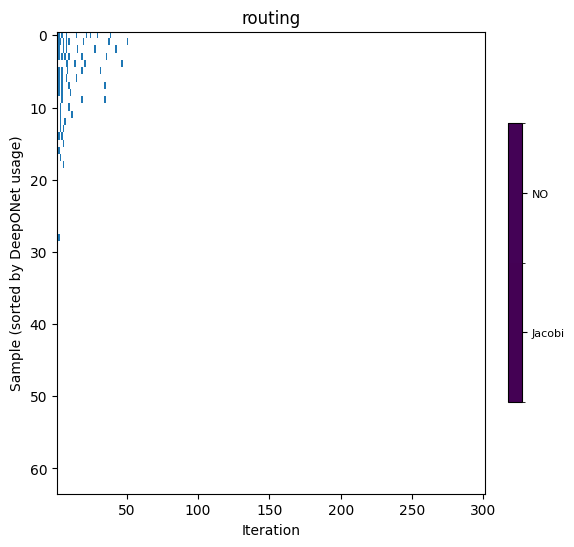

In [54]:
from matplotlib.colors import ListedColormap, BoundaryNorm
base_colors = plt.cm.tab10.colors
K = 2
cmap_colors = [base_colors[i % 10] for i in range(K)]
cmap = ListedColormap(cmap_colors[:K])
bounds = np.arange(-0.5, K + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)
fig = plt.figure(figsize=(6, 6))
best_solver_2 = np.zeros((best_solver.shape[0], best_solver.shape[1], 3))
best_solver_2[best_solver == 1] = np.array([0.12156862745098039, 0.4666666666666667, 0.7058823529411765])
best_solver_2[best_solver == 0] = np.array([1.0, 1.0, 1.0])
ax = fig.add_subplot(1, 1, 1)
im = ax.imshow(best_solver_2.transpose(1, 0, 2)[sort_order,:, :], aspect="auto",
                    interpolation="nearest", extent=[1, max_iters + 1, n_samples - 0.5, -0.5], norm = norm)
ax.set_xlabel("Iteration")
ax.set_ylabel("Sample (sorted by DeepONet usage)")
ax.set_title(f"routing")
cbar = plt.colorbar(im, ax=ax, ticks=np.arange(K), fraction=0.03)
cbar.ax.set_yticklabels(["Jacobi", "NO"], fontsize=8)
plt.show()

(300, 64)


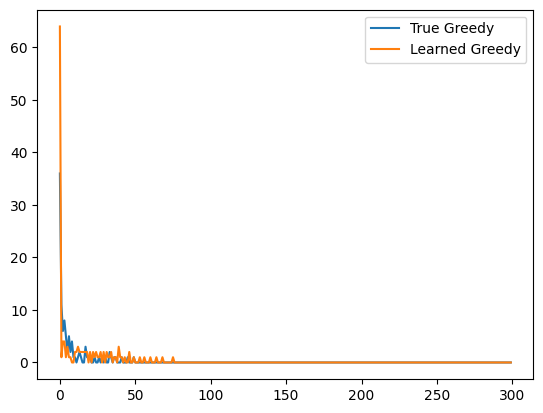

In [55]:
# Solver patterns
print(best_solver.shape)
# plt.plot(best_solver)
fig = plt.figure()
ax = fig.add_subplot(1,1, 1)
ax.plot(np.sum(best_solver, axis = -1), label = "True Greedy")
ax.plot(np.sum(solver_decision_greedy, axis = -1), label = "Learned Greedy")
ax.legend()

In [56]:
best_solver

array([[0, 1, 1, ..., 1, 0, 1],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(300, 64))

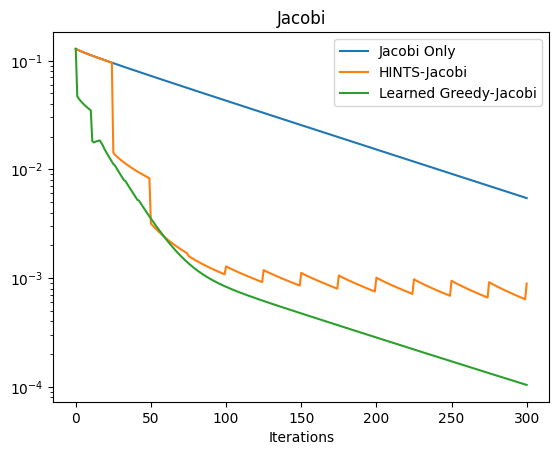

In [57]:
index_of_interest = 43
plt.plot(errors_constant_jacobi[:, index_of_interest], label='Jacobi Only')
plt.plot(errors_hints[:, index_of_interest], label='HINTS-Jacobi')
plt.plot(errors_greedy[:, index_of_interest], label='Learned Greedy-Jacobi')
# plt.plot(error_true[:, index_of_interest], label = "True Greedy-Jacobi")
plt.legend()
plt.title("Jacobi")
plt.xlabel("Iterations")
plt.yscale("log")

In [58]:
auc_true = np.trapezoid(error_true, axis = 0)
auc_constant_jacobi = np.trapezoid(errors_constant_jacobi, axis = 0)
auc_hints = np.trapezoid(errors_hints, axis = 0)
auc_greedy = np.trapezoid(errors_greedy, axis = 0)
print(f"{np.mean(auc_true)} +/- {np.std(auc_true)}")
print(f"{np.mean(auc_constant_jacobi)} +/- {np.std(auc_constant_jacobi)}")
print(f"{np.mean(auc_hints)} +/- {np.std(auc_hints)}")
print(f"{np.mean(auc_greedy)} +/- {np.std(auc_greedy)}")


0.11324049532413483 +/- 0.20726840198040009
1.0638121366500854 +/- 2.552661418914795
0.46336856484413147 +/- 0.7160477638244629
0.18651187419891357 +/- 0.3720567524433136


[ 0.1187816   0.13579394  0.14976189  0.11463703  0.24897671  0.11954626
  0.8633404   0.11949136  0.11496946  0.639032    0.14325999  0.13368994
  0.11672695  1.7566736   0.11479406  0.1316446   0.12184104  0.10264699
  0.11463419  0.17420453  0.12989804  0.15068959  0.11560363  0.16915025
  0.18107794  0.11507019  0.20918794  0.14557247  0.14392132  0.79162174
  2.0970554   0.11453094  0.11615372  0.13057531  0.1479676   0.8387339
  0.11475845  0.14055456  0.11560563  0.11962597  0.12380774  0.12631005
  0.11737575  2.2223296   0.15954706  0.12920453  0.1885271   0.11475933
  0.11486553  0.26673338  0.11905396  0.12696481  0.14217293 -0.00513685
  0.14253849  0.48418936  0.11731745  0.11511827  0.11979282  0.11855477
  0.12389233  0.3396744   0.12342707  0.46600628]
0.2768567
0.0


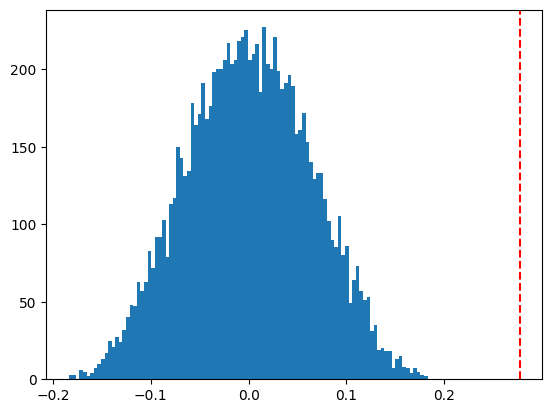

In [59]:
diff = auc_hints - auc_greedy
print(diff)
t_obs = diff.mean()
print(t_obs)
n_perm = 10000
signs = np.random.choice([-1.0, 1.0], size = (n_perm, diff.size))
t_perm = (signs * diff).mean(axis = 1)
pval = np.sum(t_perm >= t_obs)/n_perm
print(pval)
plt.hist(t_perm, bins = 100)
plt.axvline(x=t_obs, color='r', linestyle='--', label=f'Mean Y ({t_obs:.2f})')


0.2768567
0.4258699417114258
1.1470206043862063e-06


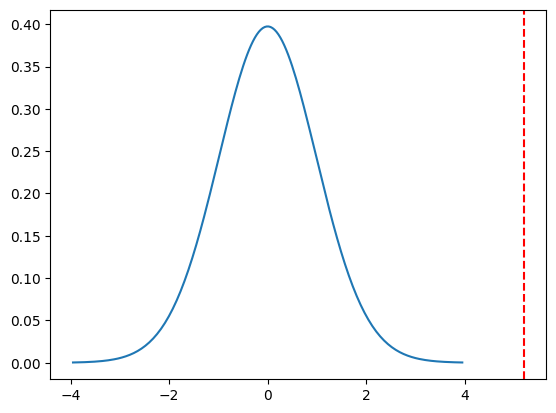

In [60]:
from scipy.stats import t
stdd = np.std(diff)
print(t_obs)
print(f"{np.std(diff)}")
test_stat = t_obs/(stdd/np.sqrt(n_samples))
df = n_samples - 1
print(1-t.cdf(test_stat, df))
x = np.linspace(t.ppf(0.0001, df),
                t.ppf(0.9999, df), 200)
plt.plot(x, t.pdf(x, df),  label='t pdf')
plt.axvline(x=test_stat, color='r', linestyle='--', label=f'Mean Y ({t_obs:.2f})')

In [61]:
from scipy.stats import ttest_rel
ttest_rel(auc_hints, auc_greedy, alternative="greater").pvalue

np.float64(1.336947597353975e-06)

[-1.6451457e-05  2.0299853e-05  5.1859457e-05 -2.2512462e-05
  2.7419266e-04 -1.3074168e-05  1.9836745e-03  2.4692781e-06
 -2.1991813e-05  1.6528639e-03  3.0129875e-05  1.6270656e-05
 -1.8511479e-05  3.1719112e-03 -2.2218321e-05  1.5633783e-05
 -3.5142020e-06  8.3702544e-05 -2.2518268e-05  9.9531266e-05
  7.0018887e-06  4.7153939e-05 -2.0569723e-05  8.9653833e-05
  1.2976564e-04 -2.1641361e-05  2.7343314e-04  4.2483713e-05
  2.5983745e-05  1.2892673e-03  5.3330883e-03 -2.2723440e-05
 -1.9291587e-05  7.1497961e-06  4.4132641e-05  1.8667667e-03
 -2.2177668e-05  2.7012087e-05 -2.0811258e-05 -1.6361862e-05
 -5.2709438e-06  1.2917826e-06 -1.6202299e-05  5.3390251e-03
  6.7818190e-05  9.0423237e-06  1.3930027e-04 -2.2269296e-05
 -2.1973507e-05  2.8286522e-04 -1.3497274e-05  2.6719972e-06
  3.3951095e-05 -2.7303890e-05  1.1738874e-04  1.0108599e-03
 -1.6489312e-05  4.9165753e-04  3.9151364e-05 -1.3306602e-05
 -1.2508754e-06  5.4075435e-04 -5.9577615e-06  3.7697661e-03]
0.00043754818
0.0011365

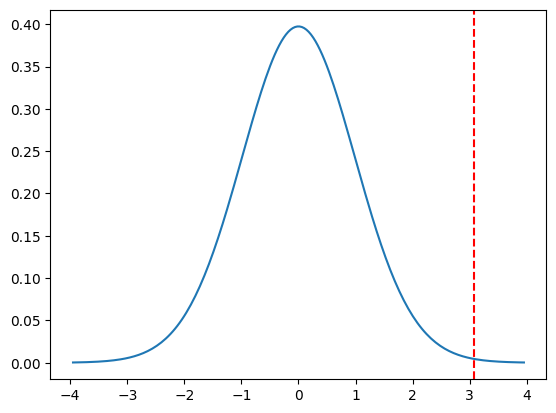

In [62]:
diff_2 = errors_constant_jacobi[-1] - errors_greedy[-1]
print(diff_2)
t_obs = diff_2.mean()
stdd = np.std(diff_2)
print(t_obs)
print(f"{np.std(diff_2)}")
test_stat = t_obs/(stdd/np.sqrt(n_samples))
df = n_samples - 1
print(1-t.cdf(test_stat, df))
x = np.linspace(t.ppf(0.0001, df),
                t.ppf(0.9999, df), 200)
plt.plot(x, t.pdf(x, df),  label='t pdf')
plt.axvline(x=test_stat, color='r', linestyle='--', label=f'Mean Y ({t_obs:.2f})')

In [63]:
df_error = pd.DataFrame({"Methods": ["jacobi only", "HINTS-jacobi", "Greedy-jacobi", "True-Greedy-jacobi","gs only", "HINTS-gs", "Greedy-gs", "True-Greedy-gs", "Greedy-gs,jacobi", "mg only", "HINTS-mg", "Greedy-mg", "True-Greedy-mg"]})
df_error["FinalError_2d_Poisson"] = ""
df_error["AUC_Error_2d_Poisson"] = ""

df_error["FinalError_2d_Helmholtz"] = ""
df_error["AUC_Error_2d_Helmholtz"] = ""

df_error["FinalError_2d_Convdiff"] = ""
df_error["AUC_Error_2d_Convdiff"] = ""
df_error = df_error.set_index("Methods")

In [64]:
df_error

,FinalError_2d_Poisson,AUC_Error_2d_Poisson,FinalError_2d_Helmholtz,AUC_Error_2d_Helmholtz,FinalError_2d_Convdiff,AUC_Error_2d_Convdiff
Methods,,,,,,
jacobi only,,,,,,
HINTS-jacobi,,,,,,
Greedy-jacobi,,,,,,
True-Greedy-jacobi,,,,,,
gs only,,,,,,
HINTS-gs,,,,,,
Greedy-gs,,,,,,
True-Greedy-gs,,,,,,
"Greedy-gs,jacobi",,,,,,


In [65]:
df_error.loc["jacobi only", "AUC_Error_2d_Poisson"] = f"{(np.mean(errors_constant_jacobi[-1])*(10**3)).item():.3f} ({(np.std(errors_constant_jacobi[-1])*(10**3)).item():.3f})"

In [84]:
if os.path.exists(f"../results/separate_{ml_model_type}_{ml_model_name}_error_comparison.csv"):
    df_error = pd.read_csv(f"../results/separate_{ml_model_type}_{ml_model_name}_error_comparison.csv")
    df_error.set_index("Methods", inplace = True)

In [85]:
df_error

,FinalError_2d_Poisson,Mean_FinalError_2d_Poisson,Std_FinalError_2d_Poisson,pval_FinalError_2d_Poisson,AUC_Error_2d_Poisson,Mean_AUC_Error_2d_Poisson,Std_AUC_Error_2d_Poisson,pval_AUC_Error_2d_Poisson,FinalError_2d_Helmholtz,Mean_FinalError_2d_Helmholtz,...,Std_AUC_Error_2d_Helmholtz,pval_AUC_Error_2d_Helmholtz,FinalError_2d_Convdiff,Mean_FinalError_2d_Convdiff,Std_FinalError_2d_Convdiff,pval_FinalError_2d_Convdiff,AUC_Error_2d_Convdiff,Mean_AUC_Error_2d_Convdiff,Std_AUC_Error_2d_Convdiff,pval_AUC_Error_2d_Convdiff
Methods,,,,,,,,,,,,,,,,,,,,,
jacobi only,0.496 (1.213),4.958621e-04,1.213320e-03,1.645181e-03,1.064 (2.553),1.063812,2.552661,1.363963e-03,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HINTS-jacobi,0.761 (0.019),7.613670e-04,1.934074e-05,5.290220e-48,0.463 (0.716),0.463369,0.716048,1.336957e-06,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Learned Greedy-jacobi,0.058 (0.137),5.831372e-05,1.367827e-04,NaN,0.187 (0.372),0.186512,0.372057,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
True-Greedy-jacobi,0.022 (0.018),2.201438e-05,1.828978e-05,NaN,0.113 (0.207),0.113240,0.207268,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gs only,0.025 (0.060),2.453248e-05,6.003496e-05,1.751365e-03,0.563 (1.350),0.562705,1.350469,1.393885e-03,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HINTS-gs,0.724 (0.000),7.243844e-04,3.321720e-08,1.874376e-111,0.382 (0.582),0.382109,0.582431,4.302712e-09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Learned Greedy-gs,0.006 (0.013),6.173718e-06,1.317386e-05,NaN,0.161 (0.341),0.161272,0.340656,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
True-Greedy-gs,0.001 (0.001),1.125666e-06,9.083818e-07,NaN,0.067 (0.123),0.066889,0.122807,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mg only,0.000 (0.000),4.043122e-08,9.834797e-08,9.999941e-01,0.062 (0.149),0.061979,0.148734,1.194257e-02,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [86]:
df_error[["FinalError_2d_Poisson","pval_FinalError_2d_Poisson", "AUC_Error_2d_Poisson", "pval_AUC_Error_2d_Poisson"]].to_latex()

'\\begin{tabular}{llrlr}\n\\toprule\n & FinalError_2d_Poisson & pval_FinalError_2d_Poisson & AUC_Error_2d_Poisson & pval_AUC_Error_2d_Poisson \\\\\nMethods &  &  &  &  \\\\\n\\midrule\njacobi only & 0.496 (1.213) & 0.001645 & 1.064 (2.553) & 0.001364 \\\\\nHINTS-jacobi & 0.761 (0.019) & 0.000000 & 0.463 (0.716) & 0.000001 \\\\\nLearned Greedy-jacobi & 0.058 (0.137) & NaN & 0.187 (0.372) & NaN \\\\\nTrue-Greedy-jacobi & 0.022 (0.018) & NaN & 0.113 (0.207) & NaN \\\\\ngs only & 0.025 (0.060) & 0.001751 & 0.563 (1.350) & 0.001394 \\\\\nHINTS-gs & 0.724 (0.000) & 0.000000 & 0.382 (0.582) & 0.000000 \\\\\nLearned Greedy-gs & 0.006 (0.013) & NaN & 0.161 (0.341) & NaN \\\\\nTrue-Greedy-gs & 0.001 (0.001) & NaN & 0.067 (0.123) & NaN \\\\\nmg only & 0.000 (0.000) & 0.999994 & 0.062 (0.149) & 0.011943 \\\\\nHINTS-mg & 0.081 (0.000) & 0.000000 & 0.077 (0.139) & 0.000000 \\\\\nLearned Greedy-mg & 0.000 (0.000) & NaN & 0.050 (0.139) & NaN \\\\\nTrue-Greedy-mg & 0.000 (0.000) & NaN & 0.018 (0.038) &

In [78]:
if os.path.exists(f"../results/multiple_solvers_{ml_model_type}_{ml_model_name}_error_comparison.csv"):
    df_error = pd.read_csv(f"../results/multiple_solvers_{ml_model_type}_{ml_model_name}_error_comparison.csv")
    df_error.set_index("Methods", inplace = True)
df_error

,FinalError_2d_Poisson,Mean_FinalError_2d_Poisson,Std_FinalError_2d_Poisson,AUC_Error_2d_Poisson,Mean_AUC_Error_2d_Poisson,Std_AUC_Error_2d_Poisson,FinalError_2d_Helmholtz,Mean_FinalError_2d_Helmholtz,Std_FinalError_2d_Helmholtz,AUC_Error_2d_Helmholtz,Mean_AUC_Error_2d_Helmholtz,Std_AUC_Error_2d_Helmholtz,FinalError_2d_Convdiff,Mean_FinalError_2d_Convdiff,Std_FinalError_2d_Convdiff,AUC_Error_2d_Convdiff,Mean_AUC_Error_2d_Convdiff,Std_AUC_Error_2d_Convdiff
Methods,,,,,,,,,,,,,,,,,,
Learned Greedy-Jacobi w/ 2 solvers,0.298 (1.113),2.975624e-04,1.113045e-03,0.657 (2.305),0.656563,2.304565,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
True-Greedy-Jacobi w/ 2 solvers,0.022 (0.018),2.201438e-05,1.828978e-05,0.113 (0.207),0.113240,0.207268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Learned Greedy-Jacobi w/ 3 solvers,0.223 (0.914),2.230104e-04,9.135016e-04,0.521 (1.899),0.521176,1.899470,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
True-Greedy-Jacobi w/ 3 solvers,0.021 (0.017),2.122573e-05,1.654292e-05,0.113 (0.207),0.113094,0.206755,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Learned Greedy-Jacobi w/ 4 solvers,0.496 (1.213),4.958621e-04,1.213320e-03,1.064 (2.553),1.063812,2.552661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
True-Greedy-Jacobi w/ 4 solvers,0.069 (0.145),6.858855e-05,1.454958e-04,0.178 (0.391),0.177718,0.391256,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Learned Greedy-Jacobi w/ 5 solvers,0.649 (2.041),6.489647e-04,2.041152e-03,0.934 (2.735),0.933743,2.734833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
True-Greedy-Jacobi w/ 5 solvers,0.021 (0.017),2.122573e-05,1.654292e-05,0.113 (0.207),0.113094,0.206755,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Learned Greedy-Jacobi w/ 6 solvers,0.575 (1.991),5.751696e-04,1.991295e-03,0.865 (2.844),0.864556,2.844497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
df_error[["FinalError_2d_Poisson", "AUC_Error_2d_Poisson"]].to_latex()

'\\begin{tabular}{lll}\n\\toprule\n & FinalError_2d_Poisson & AUC_Error_2d_Poisson \\\\\nMethods &  &  \\\\\n\\midrule\nLearned Greedy-Jacobi w/ 2 solvers & 0.298 (1.113) & 0.657 (2.305) \\\\\nTrue-Greedy-Jacobi w/ 2 solvers & 0.022 (0.018) & 0.113 (0.207) \\\\\nLearned Greedy-Jacobi w/ 3 solvers & 0.223 (0.914) & 0.521 (1.899) \\\\\nTrue-Greedy-Jacobi w/ 3 solvers & 0.021 (0.017) & 0.113 (0.207) \\\\\nLearned Greedy-Jacobi w/ 4 solvers & 0.496 (1.213) & 1.064 (2.553) \\\\\nTrue-Greedy-Jacobi w/ 4 solvers & 0.069 (0.145) & 0.178 (0.391) \\\\\nLearned Greedy-Jacobi w/ 5 solvers & 0.649 (2.041) & 0.934 (2.735) \\\\\nTrue-Greedy-Jacobi w/ 5 solvers & 0.021 (0.017) & 0.113 (0.207) \\\\\nLearned Greedy-Jacobi w/ 6 solvers & 0.575 (1.991) & 0.865 (2.844) \\\\\nTrue-Greedy-Jacobi w/ 6 solvers & 0.021 (0.017) & 0.113 (0.207) \\\\\nLearned Greedy-SOR w/ 2 solvers & NaN & NaN \\\\\nTrue-Greedy-SOR w/ 2 solvers & NaN & NaN \\\\\nLearned Greedy-SOR w/ 3 solvers & 0.001 (0.006) & 0.186 (0.627) \\\\

In [70]:
results_dir = "../results"

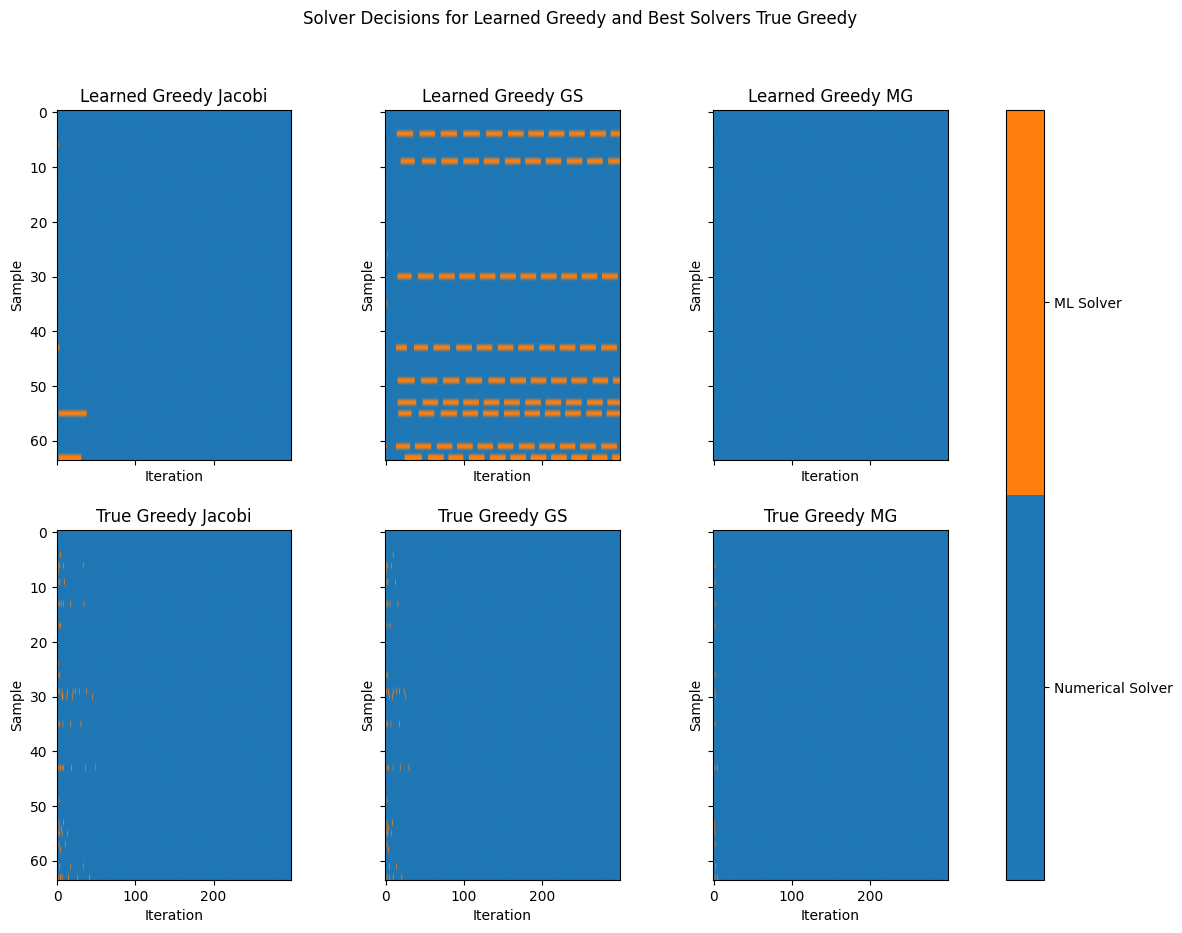

In [71]:
if os.path.exists(f"../results/{ml_model_type}_{ml_model_name}_{equation}_{boundary}_{dim}d_{in_channels}c_solver_decisions_2.pkl"):
    fig, axes = pickle.load(open(f"{results_dir}/{ml_model_type}_{ml_model_name}_{equation}_{boundary}_{dim}d_{in_channels}c_solver_decisions_2.pkl", "rb"))

[[1 1 1 ... 0 1 1]
 [1 1 0 ... 0 0 1]
 [1 0 0 ... 0 1 1]
 ...
 [1 1 1 ... 0 0 1]
 [0 1 1 ... 0 0 1]
 [0 1 0 ... 1 1 1]]


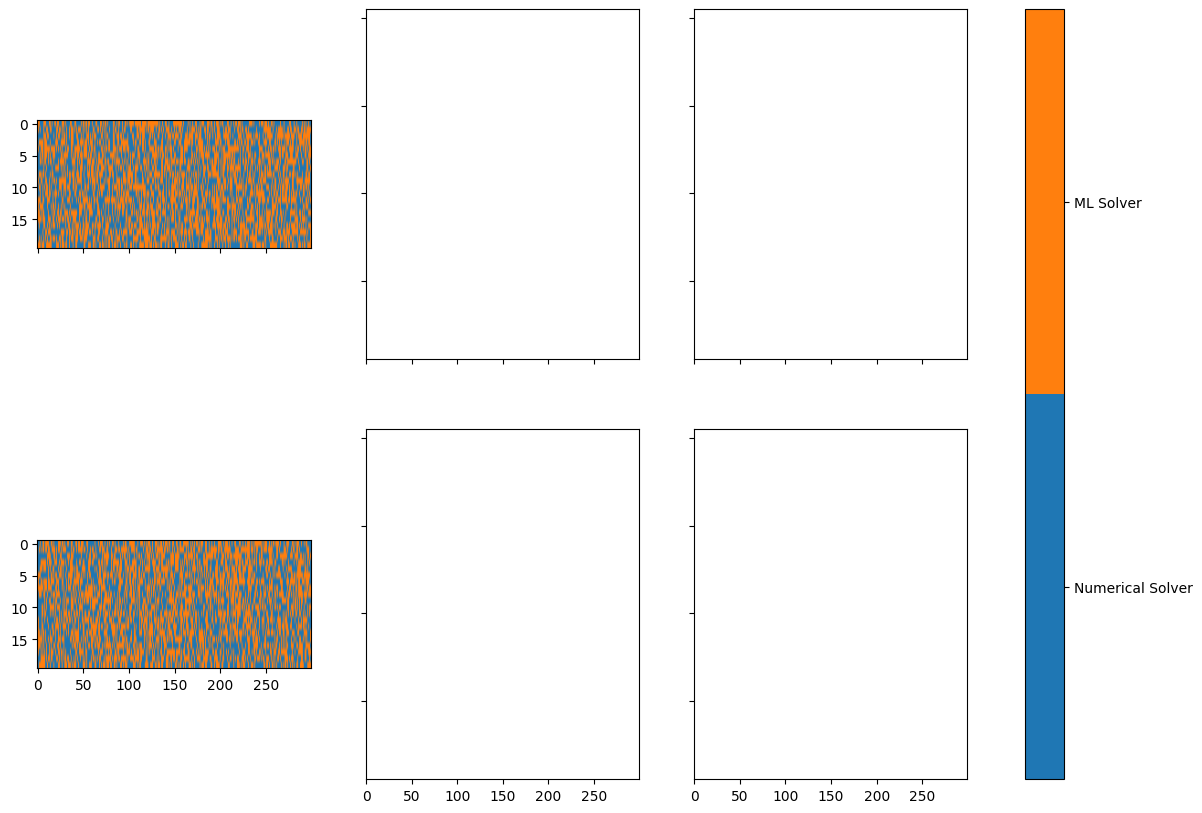

In [72]:
from matplotlib import colors
fig, axes = plt.subplots(ncols = 3, nrows = 2, sharey = True, sharex = True, figsize = (15, 10))
jac_decision = np.random.randint(low = 0, high = 2, size = (300, 20))
print(jac_decision)
two_colors = ["tab:blue", "tab:orange"]
cmap = colors.ListedColormap(two_colors)
ax = axes[0, 0].imshow(jac_decision.transpose(), cmap = cmap, aspect = 7)
true_jac_decision = np.random.randint(low = 0, high = 2, size = (300, 20))
axes[1, 0].imshow(true_jac_decision.transpose(), cmap = cmap, aspect = 7)
cbar = fig.colorbar(ax, ax = axes, location = "right")
cbar.ax.yaxis.set_label_position("right")
cbar.set_ticks([0.25, 0.75])
cbar.set_ticklabels(["Numerical Solver", "ML Solver"])

In [101]:
num_solvers = 2

In [102]:
np.linspace((num_solvers - 1)/(2*num_solvers), (num_solvers - 1)/(2*num_solvers) + (num_solvers - 1)*(num_solvers - 1)/(num_solvers), num_solvers)

array([0.25, 0.75])